# Chapter 11 Bayesian Gaussian Processes: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-11-bayesian-gaussian-processes-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

In [1]:
"""
Interactive figures for "Bayesian Nonlinear Regression: Gaussian Processes" (Part 3).

Reuses the concurrent-load / checkout-API-latency saturation scenario from Chapter 6
(chapter-06-regression-splines-plots.py) so the two chapters share one dataset. Fits use
scikit-learn's GaussianProcessRegressor, the standard entry point for GP regression in Python.

Run directly to regenerate every figure:
    python chapters/chapter-bayes-gaussian-processes-plots.py
"""

import os

import numpy as np
import plotly.graph_objects as go
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, WhiteKernel

RNG = np.random.default_rng(7)
OUT_DIR = os.path.join(os.path.dirname(os.path.abspath(＿_file_＿)), "..", "_generated")
os.makedirs(OUT_DIR, exist_ok=True)


In [2]:
def save(fig: go.Figure, name: str) -> str:
    path = os.path.join(OUT_DIR, f"{name}.html")
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    return path


In [3]:


def saturation_curve(rho: np.ndarray, base_ms: float = 20.0) -> np.ndarray:
    """Mean latency under an M/M/1-style saturation curve as utilization rho -> 1.
    Matches chapter-06-regression-splines-plots.py's data-generating process."""
    return base_ms / (1.0 - rho)


In [4]:


def simulated_load_latency(n: int = 30, noise_scale: float = 3.0, rho_max: float = 0.90):
    rho = np.sort(RNG.uniform(0.05, rho_max, size=n))
    mean_latency = saturation_curve(rho)
    latency = mean_latency + RNG.normal(0, noise_scale, size=n)
    return rho, latency


In [5]:


# ---------------------------------------------------------------------------
# Figure 1: sample functions from a GP prior at different length-scales
# ---------------------------------------------------------------------------
def fig_prior_samples() -> go.Figure:
    x_grid = np.linspace(0, 1, 200).reshape(-1, 1)
    length_scales = [0.03, 0.1, 0.3, 1.0]
    frames = []
    for ls in length_scales:
        gp = GaussianProcessRegressor(kernel=RBF(length_scale=ls), random_state=0)
        samples = gp.sample_y(x_grid, n_samples=5, random_state=1)
        traces = [
            go.Scatter(x=x_grid.ravel(), y=samples[:, i], mode="lines",
                       line=dict(width=1.6), showlegend=False)
            for i in range(samples.shape[1])
        ]
        frames.append(go.Frame(name=f"{ls:.2f}", data=traces))

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Five functions sampled from an RBF-kernel GP prior, before any data",
        xaxis_title="x (scaled utilization)",
        yaxis_title="sampled function value",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "length-scale: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [6]:


# ---------------------------------------------------------------------------
# Figure 2: RBF vs Matern kernel sample comparison
# ---------------------------------------------------------------------------
def fig_kernel_comparison() -> go.Figure:
    x_grid = np.linspace(0, 1, 200).reshape(-1, 1)
    kernels = {
        "RBF (infinitely smooth)": RBF(length_scale=0.15),
        "Matern, nu=1.5 (rougher)": Matern(length_scale=0.15, nu=1.5),
        "Matern, nu=2.5 (in between)": Matern(length_scale=0.15, nu=2.5),
    }
    frames = []
    for name, kernel in kernels.items():
        gp = GaussianProcessRegressor(kernel=kernel, random_state=0)
        samples = gp.sample_y(x_grid, n_samples=4, random_state=2)
        traces = [
            go.Scatter(x=x_grid.ravel(), y=samples[:, i], mode="lines",
                       line=dict(width=1.6), showlegend=False)
            for i in range(samples.shape[1])
        ]
        frames.append(go.Frame(name=name, data=traces))

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="Same length-scale, different kernel: smoothness assumption changes the samples",
        xaxis_title="x (scaled utilization)",
        yaxis_title="sampled function value",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "kernel: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [7]:


# ---------------------------------------------------------------------------
# Figure 3: posterior mean + credible band as the amount of observed data grows
# ---------------------------------------------------------------------------
def fig_posterior_fit() -> go.Figure:
    rho_full, latency_full = simulated_load_latency(n=60, noise_scale=3.0)
    grid = np.linspace(0.03, 0.92, 250).reshape(-1, 1)
    true_curve = saturation_curve(grid.ravel())
    sample_sizes = [5, 10, 20, 40, 60]
    frames = []
    for n in sample_sizes:
        rho_n, lat_n = rho_full[:n], latency_full[:n]
        kernel = RBF(length_scale=0.2, length_scale_bounds=(0.02, 2.0)) + WhiteKernel(1.0)
        gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=0)
        gp.fit(rho_n.reshape(-1, 1), lat_n)
        mean, std = gp.predict(grid, return_std=True)
        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Scatter(x=grid.ravel(), y=true_curve, mode="lines", name="true curve",
                                line=dict(color="#999", dash="dot")),
                    go.Scatter(x=np.concatenate([grid.ravel(), grid.ravel()[::-1]]),
                               y=np.concatenate([mean + 1.96 * std, (mean - 1.96 * std)[::-1]]),
                               fill="toself", fillcolor="rgba(76,120,168,0.25)",
                               line=dict(color="rgba(0,0,0,0)"), name="95% credible band",
                               showlegend=True),
                    go.Scatter(x=grid.ravel(), y=mean, mode="lines", name="posterior mean",
                               line=dict(color="#4C78A8", width=2.5)),
                    go.Scatter(x=rho_n, y=lat_n, mode="markers", name="observed",
                               marker=dict(color="#333", size=6)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="GP posterior mean and 95% credible band as more requests are observed",
        xaxis_title="Utilization (rho)",
        yaxis_title="Latency (ms)",
        yaxis_range=[0, 300],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "observations so far: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [8]:


# ---------------------------------------------------------------------------
# Figure 4: extrapolation uncertainty widening beyond the observed data range
# ---------------------------------------------------------------------------
def fig_extrapolation() -> go.Figure:
    rho, latency = simulated_load_latency(n=40, noise_scale=3.0, rho_max=0.75)
    grid = np.linspace(0.02, 0.97, 300).reshape(-1, 1)
    kernel = RBF(length_scale=0.2, length_scale_bounds=(0.02, 2.0)) + WhiteKernel(1.0)
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=0)
    gp.fit(rho.reshape(-1, 1), latency)
    mean, std = gp.predict(grid, return_std=True)

    fig = go.Figure()
    fig.add_vrect(x0=rho.max(), x1=0.97, fillcolor="#F58518", opacity=0.12, line_width=0,
                   annotation_text="beyond observed load range", annotation_position="top left")
    fig.add_trace(go.Scatter(
        x=np.concatenate([grid.ravel(), grid.ravel()[::-1]]),
        y=np.concatenate([mean + 1.96 * std, (mean - 1.96 * std)[::-1]]),
        fill="toself", fillcolor="rgba(76,120,168,0.25)",
        line=dict(color="rgba(0,0,0,0)"), name="95% credible band"))
    fig.add_trace(go.Scatter(x=grid.ravel(), y=mean, mode="lines", name="posterior mean",
                              line=dict(color="#4C78A8", width=2.5)))
    fig.add_trace(go.Scatter(x=rho, y=latency, mode="markers", name="observed",
                              marker=dict(color="#333", size=6)))
    fig.update_layout(
        title="Credible band widens sharply past the highest observed utilization",
        xaxis_title="Utilization (rho)",
        yaxis_title="Latency (ms)",
        yaxis_range=[-50, 500],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [9]:


# ---------------------------------------------------------------------------
# Figure 5: length-scale under/over-smoothing on the fitted posterior
# ---------------------------------------------------------------------------
def fig_length_scale_fit() -> go.Figure:
    rho, latency = simulated_load_latency(n=45, noise_scale=3.0)
    grid = np.linspace(0.03, 0.92, 250).reshape(-1, 1)
    true_curve = saturation_curve(grid.ravel())
    length_scales = [0.02, 0.08, 0.2, 0.6]
    frames = []
    for ls in length_scales:
        kernel = RBF(length_scale=ls, length_scale_bounds="fixed") + WhiteKernel(1.0)
        gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=0)
        gp.fit(rho.reshape(-1, 1), latency)
        mean, std = gp.predict(grid, return_std=True)
        frames.append(
            go.Frame(
                name=f"{ls:.2f}",
                data=[
                    go.Scatter(x=grid.ravel(), y=true_curve, mode="lines", name="true curve",
                                line=dict(color="#999", dash="dot")),
                    go.Scatter(x=np.concatenate([grid.ravel(), grid.ravel()[::-1]]),
                               y=np.concatenate([mean + 1.96 * std, (mean - 1.96 * std)[::-1]]),
                               fill="toself", fillcolor="rgba(229,134,25,0.20)",
                               line=dict(color="rgba(0,0,0,0)"), name="95% credible band"),
                    go.Scatter(x=grid.ravel(), y=mean, mode="lines", name="posterior mean",
                               line=dict(color="#F58518", width=2.5)),
                    go.Scatter(x=rho, y=latency, mode="markers", name="observed",
                               marker=dict(color="#333", size=6)),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames)
    fig.update_layout(
        title="A fixed length-scale can under-fit (too long) or chase noise (too short)",
        xaxis_title="Utilization (rho)",
        yaxis_title="Latency (ms)",
        yaxis_range=[0, 300],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "length-scale (held fixed, not optimized): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


In [10]:


FIGURES = {
    "chapter-bayes-gp-fig-prior-samples": fig_prior_samples,
    "chapter-bayes-gp-fig-kernel-comparison": fig_kernel_comparison,
    "chapter-bayes-gp-fig-posterior-fit": fig_posterior_fit,
    "chapter-bayes-gp-fig-extrapolation": fig_extrapolation,
    "chapter-bayes-gp-fig-length-scale-fit": fig_length_scale_fit,
}


**`chapter-bayes-gp-fig-prior-samples`**

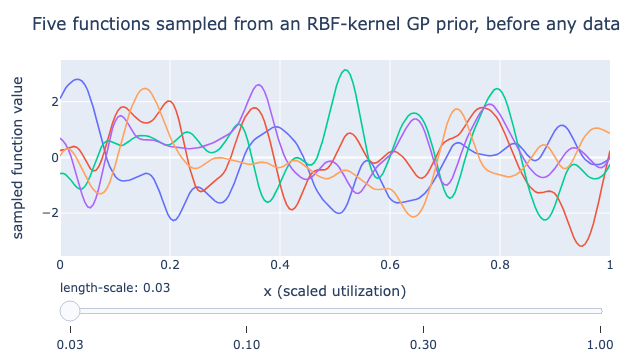

In [11]:
fig = FIGURES["chapter-bayes-gp-fig-prior-samples"]()
fig

**`chapter-bayes-gp-fig-kernel-comparison`**

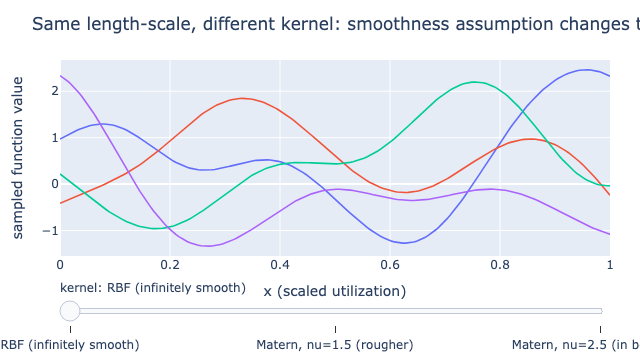

In [12]:
fig = FIGURES["chapter-bayes-gp-fig-kernel-comparison"]()
fig

**`chapter-bayes-gp-fig-posterior-fit`**

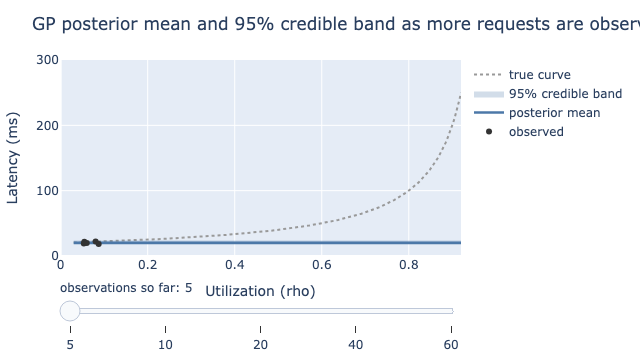

In [13]:
fig = FIGURES["chapter-bayes-gp-fig-posterior-fit"]()
fig

**`chapter-bayes-gp-fig-extrapolation`**

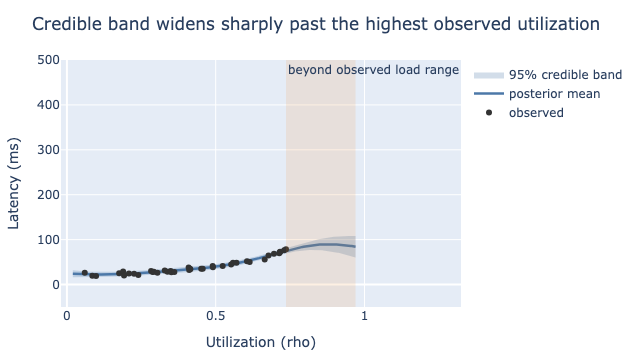

In [14]:
fig = FIGURES["chapter-bayes-gp-fig-extrapolation"]()
fig

**`chapter-bayes-gp-fig-length-scale-fit`**

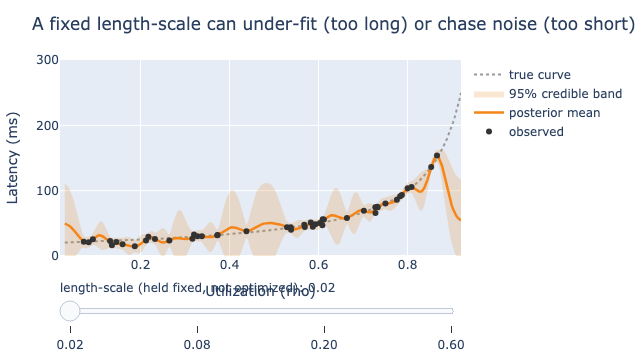

In [15]:
fig = FIGURES["chapter-bayes-gp-fig-length-scale-fit"]()
fig